In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from data.combine_timetable import combine_timetables
from data.timetable import load_gold, save_gold


In [2]:
n_freight_trains = 182

passenger = load_gold('passenger')
freight   = load_gold('freight', n_trains=n_freight_trains)

# Validatie
overlap = set(passenger['TRAIN_NO']) & set(freight['TRAIN_NO'])
print(f"Overlappende TRAIN_NO: {overlap if overlap else 'geen'}")

combined = combine_timetables(n_freight_trains)
print(combined['TRAIN_TYPE'].value_counts())
print(f"ENTRY_SECONDS range: {combined['ENTRY_SECONDS'].min():.0f}s — {combined['ENTRY_SECONDS'].max():.0f}s")

Overlappende TRAIN_NO: geen
TRAIN_TYPE
IC         6158
L          3275
freight     654
EURST       324
INT         189
ICE         126
Name: count, dtype: int64
ENTRY_SECONDS range: 0s — 86941s


In [3]:
combined.head()

,SECTION,SOURCE,TARGET,PLANNED_ENTRY,PLANNED_EXIT,TRAIN_NO,TYPE,TRAIN_TYPE,PERIOD,DYNAMICS,ENTRY_SECONDS,EXIT_SECONDS
0,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,2025-01-01 21:23:00,2025-01-01 21:26:00,10,SOURCE,ICE,EVENING,ACC-BR,76860,77040
1,BRUSSEL-NOORD -- platform 3 -- platform 3,BRUSSEL-NOORD,BRUSSEL-NOORD,2025-01-01 21:26:00,2025-01-01 21:28:00,10,WITHIN-STATION-DWELL,ICE,EVENING,0-0,77040,77160
2,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,BRUSSEL-NOORD,BRUSSEL-CONGRES,2025-01-01 21:28:00,2025-01-01 21:30:00,10,BETWEEN-STATION,ICE,EVENING,ACC-0,77160,77280
3,BRUSSEL-CONGRES -- platform 1 -- platform 1,BRUSSEL-CONGRES,BRUSSEL-CONGRES,2025-01-01 21:30:00,2025-01-01 21:30:01,10,WITHIN-STATION-PASSING,ICE,EVENING,0-0,77280,77281
4,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,BRUSSEL-CENTRAAL,2025-01-01 21:30:01,2025-01-01 21:31:00,10,BETWEEN-STATION,ICE,EVENING,0-0,77281,77340


In [4]:
save_gold(combined, source='combined', n_trains=n_freight_trains)

Opgeslagen (combined): 1210 treinen, 10726 segmenten → /Users/ddw/Desktop/Rescheduling/data/gold/combined/182


In [5]:
# =============================================================================
# Vergelijk running times tussen train types op meerdere segmenten
# =============================================================================

import matplotlib.pyplot as plt

# Running time toevoegen
df['RUNNING_TIME'] = (
    df['EXIT_SECONDS'] - df['ENTRY_SECONDS']
)

# Enkel between-station
between = df[df['TYPE'] == 'BETWEEN-STATION'].copy()

# Zoek segmenten met meerdere train types
candidate_sections = []

for section, subset in between.groupby('SECTION'):

    counts = subset.groupby('TRAIN_TYPE').size()

    # minstens 2 types
    if len(counts) < 2:
        continue

    # minstens 30 observaties per type
    if (counts >= 30).all():

        score = counts.sum()

        candidate_sections.append({
            'section': section,
            'n_types': len(counts),
            'n_obs': score
        })

# Sorteer op meeste data + meeste types
candidate_sections = sorted(
    candidate_sections,
    key=lambda x: (x['n_types'], x['n_obs']),
    reverse=True
)

print(f"Gevonden segmenten: {len(candidate_sections)}")

# ============================================================================
# Visualiseer top N segmenten
# ============================================================================

TOP_N = 5

for info in candidate_sections[:TOP_N]:

    section = info['section']

    print("=" * 80)
    print(f"SECTION: {section}")
    print("=" * 80)

    segment_df = between[
        between['SECTION'] == section
    ].copy()

    # ------------------------------------------------------------------------
    # Stats
    # ------------------------------------------------------------------------

    stats = (
        segment_df.groupby('TRAIN_TYPE')['RUNNING_TIME']
        .agg(['count', 'mean', 'std', 'median'])
        .sort_values('mean')
    )

    display(stats)

    # ------------------------------------------------------------------------
    # Histogram
    # ------------------------------------------------------------------------

    plt.figure(figsize=(12, 5))

    for ttype in sorted(segment_df['TRAIN_TYPE'].unique()):

        subset = segment_df[
            segment_df['TRAIN_TYPE'] == ttype
        ]['RUNNING_TIME']

        plt.hist(
            subset,
            bins=20,
            alpha=0.5,
            density=True,
            label=f"{ttype} (n={len(subset)})"
        )

    plt.xlabel("Running time (s)")
    plt.ylabel("Density")
    plt.title(f"Running times per train type\n{section}")
    plt.legend()
    plt.show()

    # ------------------------------------------------------------------------
    # Boxplot
    # ------------------------------------------------------------------------

    plot_data = []
    labels = []

    for ttype in sorted(segment_df['TRAIN_TYPE'].unique()):

        subset = segment_df[
            segment_df['TRAIN_TYPE'] == ttype
        ]['RUNNING_TIME']

        plot_data.append(subset)
        labels.append(ttype)

    plt.figure(figsize=(10, 5))

    plt.boxplot(
        plot_data,
        tick_labels=labels,
        showfliers=False
    )

    plt.ylabel("Running time (s)")
    plt.title(f"Running time spread per train type\n{section}")

    plt.show()

NameError: name 'df' is not defined

In [ ]:
print(df.columns)

Index(['SECTION', 'SOURCE', 'TARGET', 'PLANNED_ENTRY', 'PLANNED_EXIT',
       'TRAIN_NO', 'TYPE', 'TRAIN_TYPE', 'PERIOD', 'DYNAMICS', 'ENTRY_SECONDS',
       'EXIT_SECONDS', 'RUNNING_TIME'],
      dtype='str')


In [6]:
combined = combine_timetables(n_freight=182)

between = combined[combined['SOURCE'] != combined['TARGET']].copy()

line_codes = (
    between['SECTION']
    .str.split(':')
    .str[0]
    .value_counts()
)

print(line_codes.head(50))

SECTION
0-2      794
0-1      721
0-4      708
0-3      658
0-5      523
0-6      456
50       396
36N      304
25       270
28(1)    270
50C      180
124      129
36       126
60       105
27       101
161       84
161-2     75
28        56
26         9
50A        3
Name: count, dtype: int64


In [12]:
import pandas as pd
combined = combine_timetables(n_freight=182)

bn = combined[
    (combined['SOURCE'] == 'BRUSSEL-NOORD') &
    (combined['TARGET'] == 'BRUSSEL-NOORD')
].copy()

bn['PREVIOUS_SECTION'] = (
    bn.groupby('TRAIN_NO')['SECTION']
      .shift(1)
      .apply(lambda x: str(x).split(':')[0] if pd.notna(x) else None)
)

bn['NEXT_SECTION'] = (
    bn.groupby('TRAIN_NO')['SECTION']
      .shift(-1)
      .apply(lambda x: str(x).split(':')[0] if pd.notna(x) else None)
)
mask_internal_prev = bn['PREVIOUS_SECTION'].str.startswith('0-', na=False)

print(mask_internal_prev.value_counts())

print(
    bn.loc[mask_internal_prev,
           ['TRAIN_NO', 'PREVIOUS_SECTION', 'NEXT_SECTION', 'SECTION']]
    .head(20)
)

PREVIOUS_SECTION
False    953
Name: count, dtype: int64
Empty DataFrame
Columns: [TRAIN_NO, PREVIOUS_SECTION, NEXT_SECTION, SECTION]
Index: []


,SECTION,SOURCE,TARGET,n_train_passages,unique_trains,avg_running_time,total_occupation_time,passenger_trains,freight_trains
52,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,226,226,200.097345,45222,143,83
4,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,BRUSSEL-CENTRAAL,BRUSSEL-KAPELLEKERK,197,197,97.568528,19221,197,0
5,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,BRUSSEL-CENTRAAL,197,197,103.467005,20383,197,0
6,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,197,197,133.314721,26263,197,0
7,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,BRUSSEL-NOORD,BRUSSEL-CONGRES,197,197,120.751269,23788,197,0
0,0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES,BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,181,181,107.558011,19468,181,0
2,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,BRUSSEL-KAPELLEKERK,BRUSSEL-CENTRAAL,181,181,97.453039,17639,181,0
1,0-1:BRUSSEL-CONGRES-BRUSSEL-NOORD,BRUSSEL-CONGRES,BRUSSEL-NOORD,181,181,129.607735,23459,181,0
3,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,178,178,121.011236,21540,178,0
13,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,BRUSSEL-CENTRAAL,BRUSSEL-KAPELLEKERK,177,177,87.118644,15420,177,0


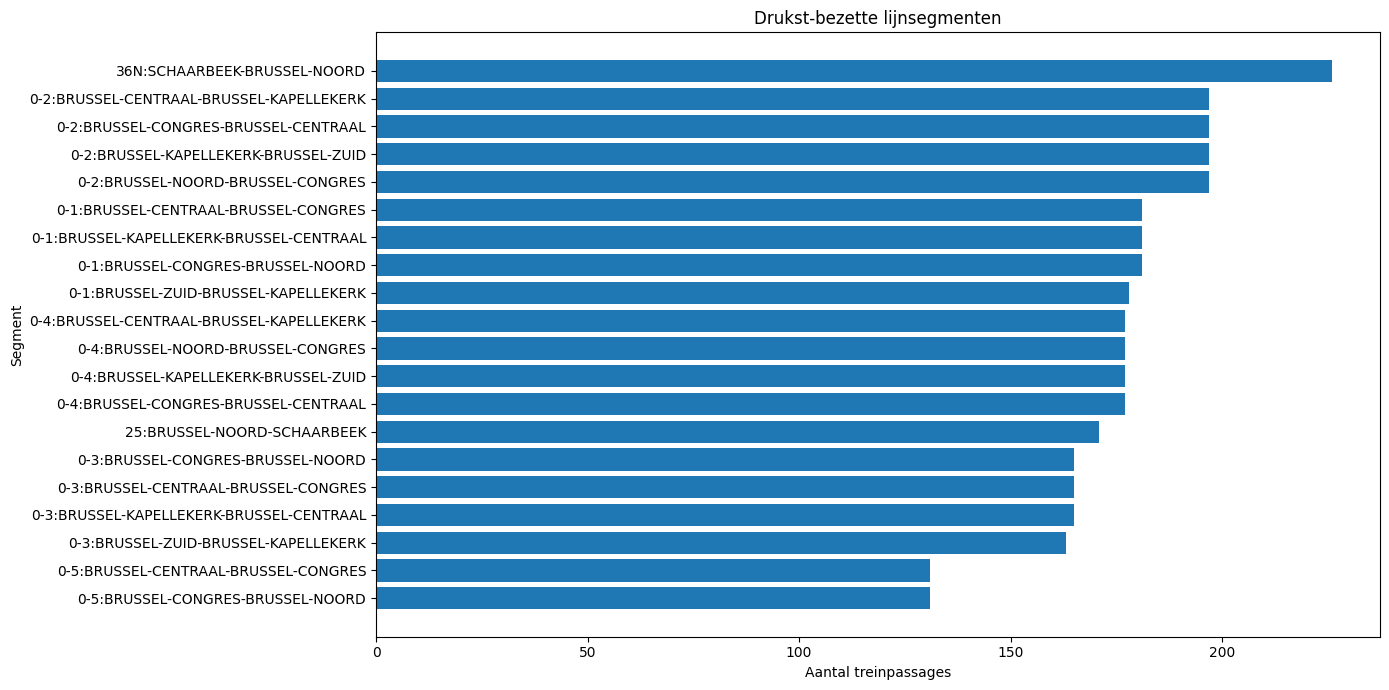

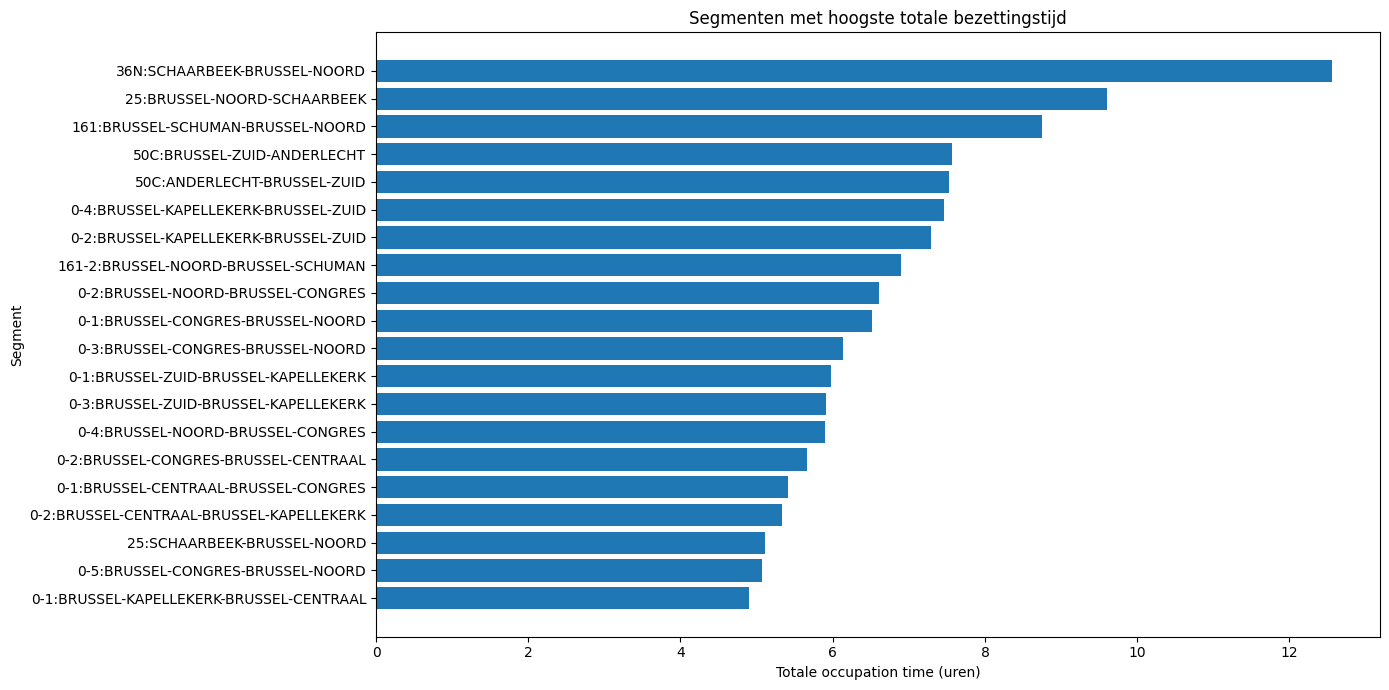

In [13]:
# Analyse drukst-bezette lijnsegmenten

import pandas as pd
import matplotlib.pyplot as plt

from data.combine_timetable import combine_timetables

# =========================
# Load timetable
# =========================

df = combine_timetables(n_freight=182)

# Enkel echte lijnsegmenten
between = df[df["SOURCE"] != df["TARGET"]].copy()

# =========================
# Segment statistics
# =========================

between["RUNNING_TIME"] = (
    between["EXIT_SECONDS"] - between["ENTRY_SECONDS"]
)

segment_stats = (
    between.groupby(["SECTION", "SOURCE", "TARGET"])
    .agg(
        n_train_passages=("TRAIN_NO", "count"),
        unique_trains=("TRAIN_NO", "nunique"),
        avg_running_time=("RUNNING_TIME", "mean"),
        total_occupation_time=("RUNNING_TIME", "sum"),
        passenger_trains=("TRAIN_TYPE", lambda x: (x != "freight").sum()),
        freight_trains=("TRAIN_TYPE", lambda x: (x == "freight").sum()),
    )
    .reset_index()
)

# Sorteer op drukte
segment_stats = segment_stats.sort_values(
    "n_train_passages",
    ascending=False
)

# =========================
# Toon top segmenten
# =========================

TOP_N = 20

display(segment_stats.head(TOP_N))

# =========================
# Plot: passages
# =========================

top_plot = segment_stats.head(TOP_N).copy()

plt.figure(figsize=(14, 7))

plt.barh(
    top_plot["SECTION"][::-1],
    top_plot["n_train_passages"][::-1]
)

plt.xlabel("Aantal treinpassages")
plt.ylabel("Segment")
plt.title("Drukst-bezette lijnsegmenten")

plt.tight_layout()
plt.show()

# =========================
# Plot: occupation time
# =========================

top_occ = segment_stats.sort_values(
    "total_occupation_time",
    ascending=False
).head(TOP_N)

plt.figure(figsize=(14, 7))

plt.barh(
    top_occ["SECTION"][::-1],
    top_occ["total_occupation_time"][::-1] / 3600
)

plt.xlabel("Totale occupation time (uren)")
plt.ylabel("Segment")
plt.title("Segmenten met hoogste totale bezettingstijd")

plt.tight_layout()
plt.show()